# Dataset Sintético de Evasão Escolar

Este notebook gera um dataset sintético com base em variáveis relacionadas à evasão escolar no ensino público do Distrito Federal. As variáveis foram definidas previamente e incluem dados do estudante, família, comunidade, escola e professores.

# Definição de evasão escolar

- Precisamos de uma definição clara de evasão escolar. Exemplo, faltou mais de 30 dias seguidos?! 
- O ideal é seguir a definição do MEC, que considera evasão escolar a falta não justificada por mais de 15 dias consecutivos, conforme ChatGPT (temos que confirmar e pegar a fonte).
- Ou podemos considerar uma definição razoável usada em outros trabalhos acadêmicos.

# Propriedades de atributos

- Precisamos definir melhor as propriedades de cada atributo para facilitar a síntese de dados. Exemplo:
  - Sexo: variável categórica (masculino, feminino, "não informado" ?). Qual a proporção de cada categoria? Se não houver, podemos usar dados do IBGE.
  - Idade: variável numérica. Qual a média, mediana e desvio padrão? OU proporção entre esses, considerando uma variável categórica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.stats import truncnorm

# Configurações iniciais
n_alunos = 100000  # número de registros

In [2]:
sexos = ['Masculino', 'Feminino', 'Outro']
# etapas = ['5º ano', '6º ano', '7º ano', '8º ano', '9º ano', '1ª série EM', '2ª série EM', '3ª série EM']
# niveis_socioeconomicos = [f'N{i}' for i in range(1, 8)]
apoio_familiar_vals = ['Alto', 'Médio', 'Baixo']
comportamento_vals = ['Bom', 'Regular', 'Ruim']
aceitacao_vals = ['Alta', 'Média', 'Baixa']
expectativa_vals = ['Alta', 'Média', 'Baixa']
engajamento_vals = ['Alto', 'Moderado', 'Baixo']
infraestrutura_vals = ['Boa', 'Regular', 'Ruim']
material_vals = ['Completa', 'Parcial', 'Insuficiente']
flex_pedagogica_vals = ['Alta', 'Média', 'Baixa']
qualidade_pedagogica_vals = ['Boa', 'Regular', 'Ruim']

idades=[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

In [3]:
# Variáveis
proporcao_evasao = 0.1 # Supondo que 10% dos alunos evadem

pesos_idades=[1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13]
pesos_idades_evadiu=[0.5/13, 1.5/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13, 1/13]

In [4]:
def gerar_idade(evadiu:bool):
    if evadiu:
        return random.choices(idades, weights=pesos_idades_evadiu)[0]
    else:
        return random.choices(idades, weights=pesos_idades)[0]

def gerar_sexo(evadiu:bool):
    if evadiu:
        return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]  # Evadidos têm menos diversidade de sexo
    else:
        return random.choices(sexos, weights=[0.48, 0.48, 0.04])[0]  # Proporção de não evadidos

def gerar_frequencia():
    media = 85
    desvio = 10

    a, b = (0 - media) / desvio, (100 - media) / desvio  # limites normalizados
    notas = truncnorm.rvs(a, b, loc=media, scale=desvio, size=n_alunos)
    return notas

def gerar_nota():
    distribuicao = {
        (0, 5): 0.25,   # 25% dos alunos com média até 5
        (5, 7): 0.35,   # 35% entre 5 e 7
        (7, 10): 0.40   # 40% entre 7 e 10
    }
    
    # selecionar faixa com base nas probabilidades
    faixas = list(distribuicao.keys())
    probs = list(distribuicao.values())
    faixa_escolhida = faixas[np.random.choice(len(faixas), p=probs)]
    
    # ordena nota uniforme dentro da faixa
    nota = np.random.uniform(faixa_escolhida[0], faixa_escolhida[1])
    
    return round(nota, 1) 

def gerar_niveis_socioeconomicos():

    distribuicao = {
        "Muito baixo": 0.10,
        "Baixo": 0.30,
        "Médio": 0.40,
        "Alto": 0.15,
        "Muito alto": 0.05
    }

    categorias = list(distribuicao.keys())
    probs = list(distribuicao.values())
    
    return np.random.choice(categorias, p=probs)

def gerar_renda():
    distribuicao = {
        (0,1): 0.05,
        (1,2): 0.35,
        (2,5): 0.45,
        (5,10): 0.10,
        (10, np.inf): 0.05
    }
    
    # escolher faixa com base nas probabilidades
    faixas = list(distribuicao.keys())
    probs = list(distribuicao.values())
    faixa_escolhida = faixas[np.random.choice(len(faixas), p=probs)]
    
    # sortear renda dentro da faixa
    if np.isinf(faixa_escolhida[1]):
        renda_sm = np.random.uniform(faixa_escolhida[0], faixa_escolhida[0] * 2)
    else:
        renda_sm = np.random.uniform(faixa_escolhida[0], faixa_escolhida[1])
    
    # converter para reais
    salario_min = 1139.4    # media do salario minimo dos ultimos 10 anos 
    renda_reais = renda_sm * salario_min
    
    return round(renda_reais, 2)

def gerar_etapa_ensino(evadiu: bool):
    """
    Retorna uma etapa de ensino.
    - Se evadiu=True: amostra segundo a distribuição de evasão por etapa.
    - Se evadiu=False: amostra segundo a distribuição geral de matrículas por etapa.
    """
    etapas = ["1° EF", "2° EF", "3° EF", "4° EF", "5° EF", "6° EF",
              "7° EF", "8° EF", "9° EF", "1° EM", "2° EM", "3° EM"]

    # dados do censo escolar de 2023 (total - matrícula Educação Infantil)
    total_matriculas = 400686 - 48259
    qtd_matriculas_etapas = np.array([28087, 29163, 33253, 28054, 28682, 29944,
                                      30364, 28886, 30368, 31195, 29372, 25056], dtype=float)

    # distribuição da proporção de alunos por etapa
    distr_etapas = qtd_matriculas_etapas / total_matriculas

    percentual_evasao_etapa = np.array([0.002, 0.001, 0.002, 0.002, 0.002, 0.01,
                                       0.014, 0.012, 0.018, 0.04, 0.046, 0.03], dtype=float)

    # calcula a distribuição de abandonos (evadidos por etapa) e normaliza
    qtd_evadidos_por_etapa = qtd_matriculas_etapas * percentual_evasao_etapa
    total_evadidos = qtd_evadidos_por_etapa.sum()
    if total_evadidos <= 0:
        distr_etapas_evasao = distr_etapas.copy()
    else:
        distr_etapas_evasao = qtd_evadidos_por_etapa / total_evadidos

    # evadiu -> usar distribuição de evasão; não evadiu -> usar distribuição geral
    weights = distr_etapas_evasao if evadiu else distr_etapas
    return random.choices(etapas, weights=weights, k=1)[0]
    
def gerar_distancia():
    return round(abs(np.random.normal(2, 1)), 1)

In [5]:

serie_evasao:list[bool] = [random.choices([True, False], weights=[proporcao_evasao, 1 - proporcao_evasao])[0] for _ in range(n_alunos) ]

# Criação do DataFrame
df = pd.DataFrame({
    'id_aluno': np.arange(1, n_alunos + 1),
    'evasao': serie_evasao,  # atributo que eu tenho e quero estimar
    'sexo': [gerar_sexo(evadir) for evadir in serie_evasao],
    'idade': [gerar_idade(evadir) for evadir in serie_evasao],
    'estudante_nis': np.random.choice([True, False], n_alunos, p=[0.3, 0.7]),
    'informou_nome_mae': np.random.choice([True, False], n_alunos, p=[0.95, 0.05]),
    'informou_nome_pai': np.random.choice([True, False], n_alunos, p=[0.7, 0.3]),
    'possui_deficiencia': np.random.choice([True, False], n_alunos, p=[0.05, 0.95]),
    'raca_cor': np.random.choice(
        ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena', 'Não declarada'],
        n_alunos,
        p=[0.35, 0.1, 0.45, 0.05, 0.02, 0.03]
    ),
    'tipo_localizacao_endereco_estudante': np.random.choice(
        ['Urbana', 'Rural'],
        n_alunos,
        p=[0.8, 0.2]
    ),
    'situacao_consolidada_no_ano': np.random.choice(
        ['Aprovado', 'Reprovado', 'Evadido', 'Em andamento'],
        n_alunos,
        p=[0.7, 0.15, 0.1, 0.05]
    ),
    'repetente': np.random.choice([True, False], n_alunos, p=[0.047, 0.953]),
    'etapa_ensino': [gerar_etapa_ensino(i) for i in serie_evasao],
    'frequencia_escolar': gerar_frequencia(),    
    'notas_medias': [gerar_nota() for _ in range(n_alunos)],
    'nivel_socioeconomico': [gerar_niveis_socioeconomicos() for _ in range(n_alunos)],
    'renda_familiar': [gerar_renda() for _ in range(n_alunos)],
    'distancia_da_escola_km': [gerar_distancia() for _ in range(n_alunos)],
    
    # ainda não criadas
    'trabalha': np.random.choice([True, False], n_alunos, p=[0.15, 0.85]),
    'trabalho_domestico_excessivo': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'problemas_de_saude': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'violencia_domestica': np.random.choice([True, False], n_alunos, p=[0.05, 0.95]),
    'gravidez_na_adolescencia': np.random.choice([True, False], n_alunos, p=[0.03, 0.97]),
    'apoio_familiar': np.random.choice(apoio_familiar_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'comportamento_em_sala': np.random.choice(comportamento_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'aceitacao_pelos_pares': np.random.choice(aceitacao_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'necessita_assistencia_social': np.random.choice([True, False], n_alunos, p=[0.3, 0.7]),
    'expectativa_retorno': np.random.choice(expectativa_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'fator_desencadeador_presente': np.random.choice([True, False], n_alunos, p=[0.1, 0.9]),
    'violencia_na_comunidade': np.random.choice([True, False], n_alunos, p=[0.2, 0.8]),
    'engajamento_com_a_escola': np.random.choice(engajamento_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'infraestrutura_escolar': np.random.choice(infraestrutura_vals, n_alunos, p=[0.5, 0.3, 0.2]),
    'disponibilidade_material_didatico': np.random.choice(material_vals, n_alunos, p=[0.6, 0.3, 0.1]),
    'flexibilidade_pedagogica': np.random.choice(flex_pedagogica_vals, n_alunos, p=[0.4, 0.4, 0.2]),
    'qualidade_pedagogica_percebida': np.random.choice(qualidade_pedagogica_vals, n_alunos, p=[0.5, 0.3, 0.2])
})

# Pontuação de risco
df['pontuacao_risco'] = (
     (100 - df['frequencia_escolar']) / 100 * 0.3 +
     (10 - df['notas_medias']) / 10 * 0.3 +
     df['repetente'].astype(int) * 0.1 +
     df['trabalha'].astype(int) * 0.1 +
     df['violencia_domestica'].astype(int) * 0.2
 )

df['pontuacao_risco'] = df['pontuacao_risco'] / df['pontuacao_risco'].max()

# Evasão confirmada
df['evasao_confirmada'] = [np.random.rand() < r for r in df['pontuacao_risco']]


In [6]:
df['etapa_ensino'].head()

0    8° EF
1    5° EF
2    9° EF
3    4° EF
4    6° EF
Name: etapa_ensino, dtype: object

In [7]:
# Visualização da distribuição da pontuação de risco
# plt.hist(df['pontuacao_risco'], bins=20, edgecolor='black')
# plt.title('Distribuição da Pontuação de Risco')
# plt.xlabel('Pontuação de risco')
# plt.ylabel('Quantidade de alunos')
# plt.show()

## Análise Exploratória

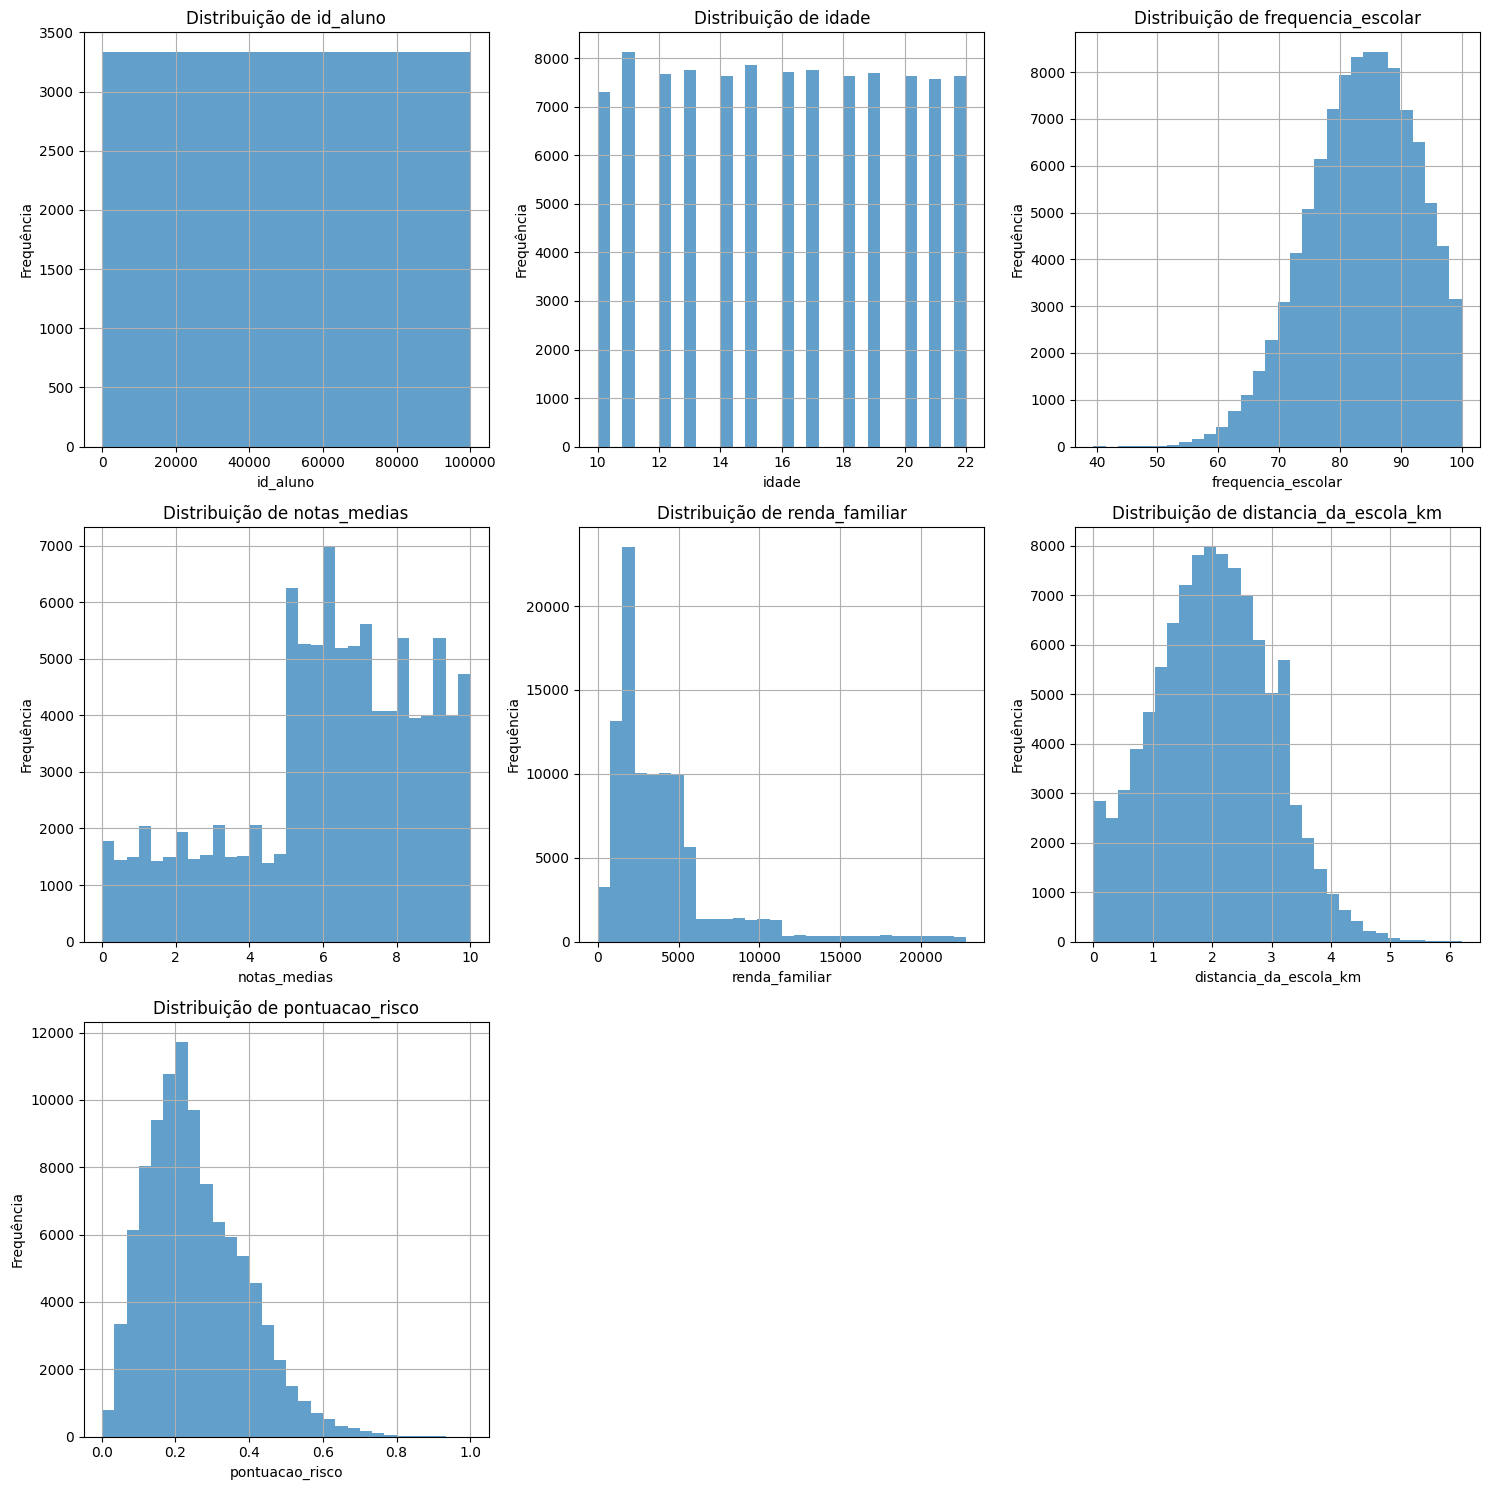

========== Var. Categóricas ==========


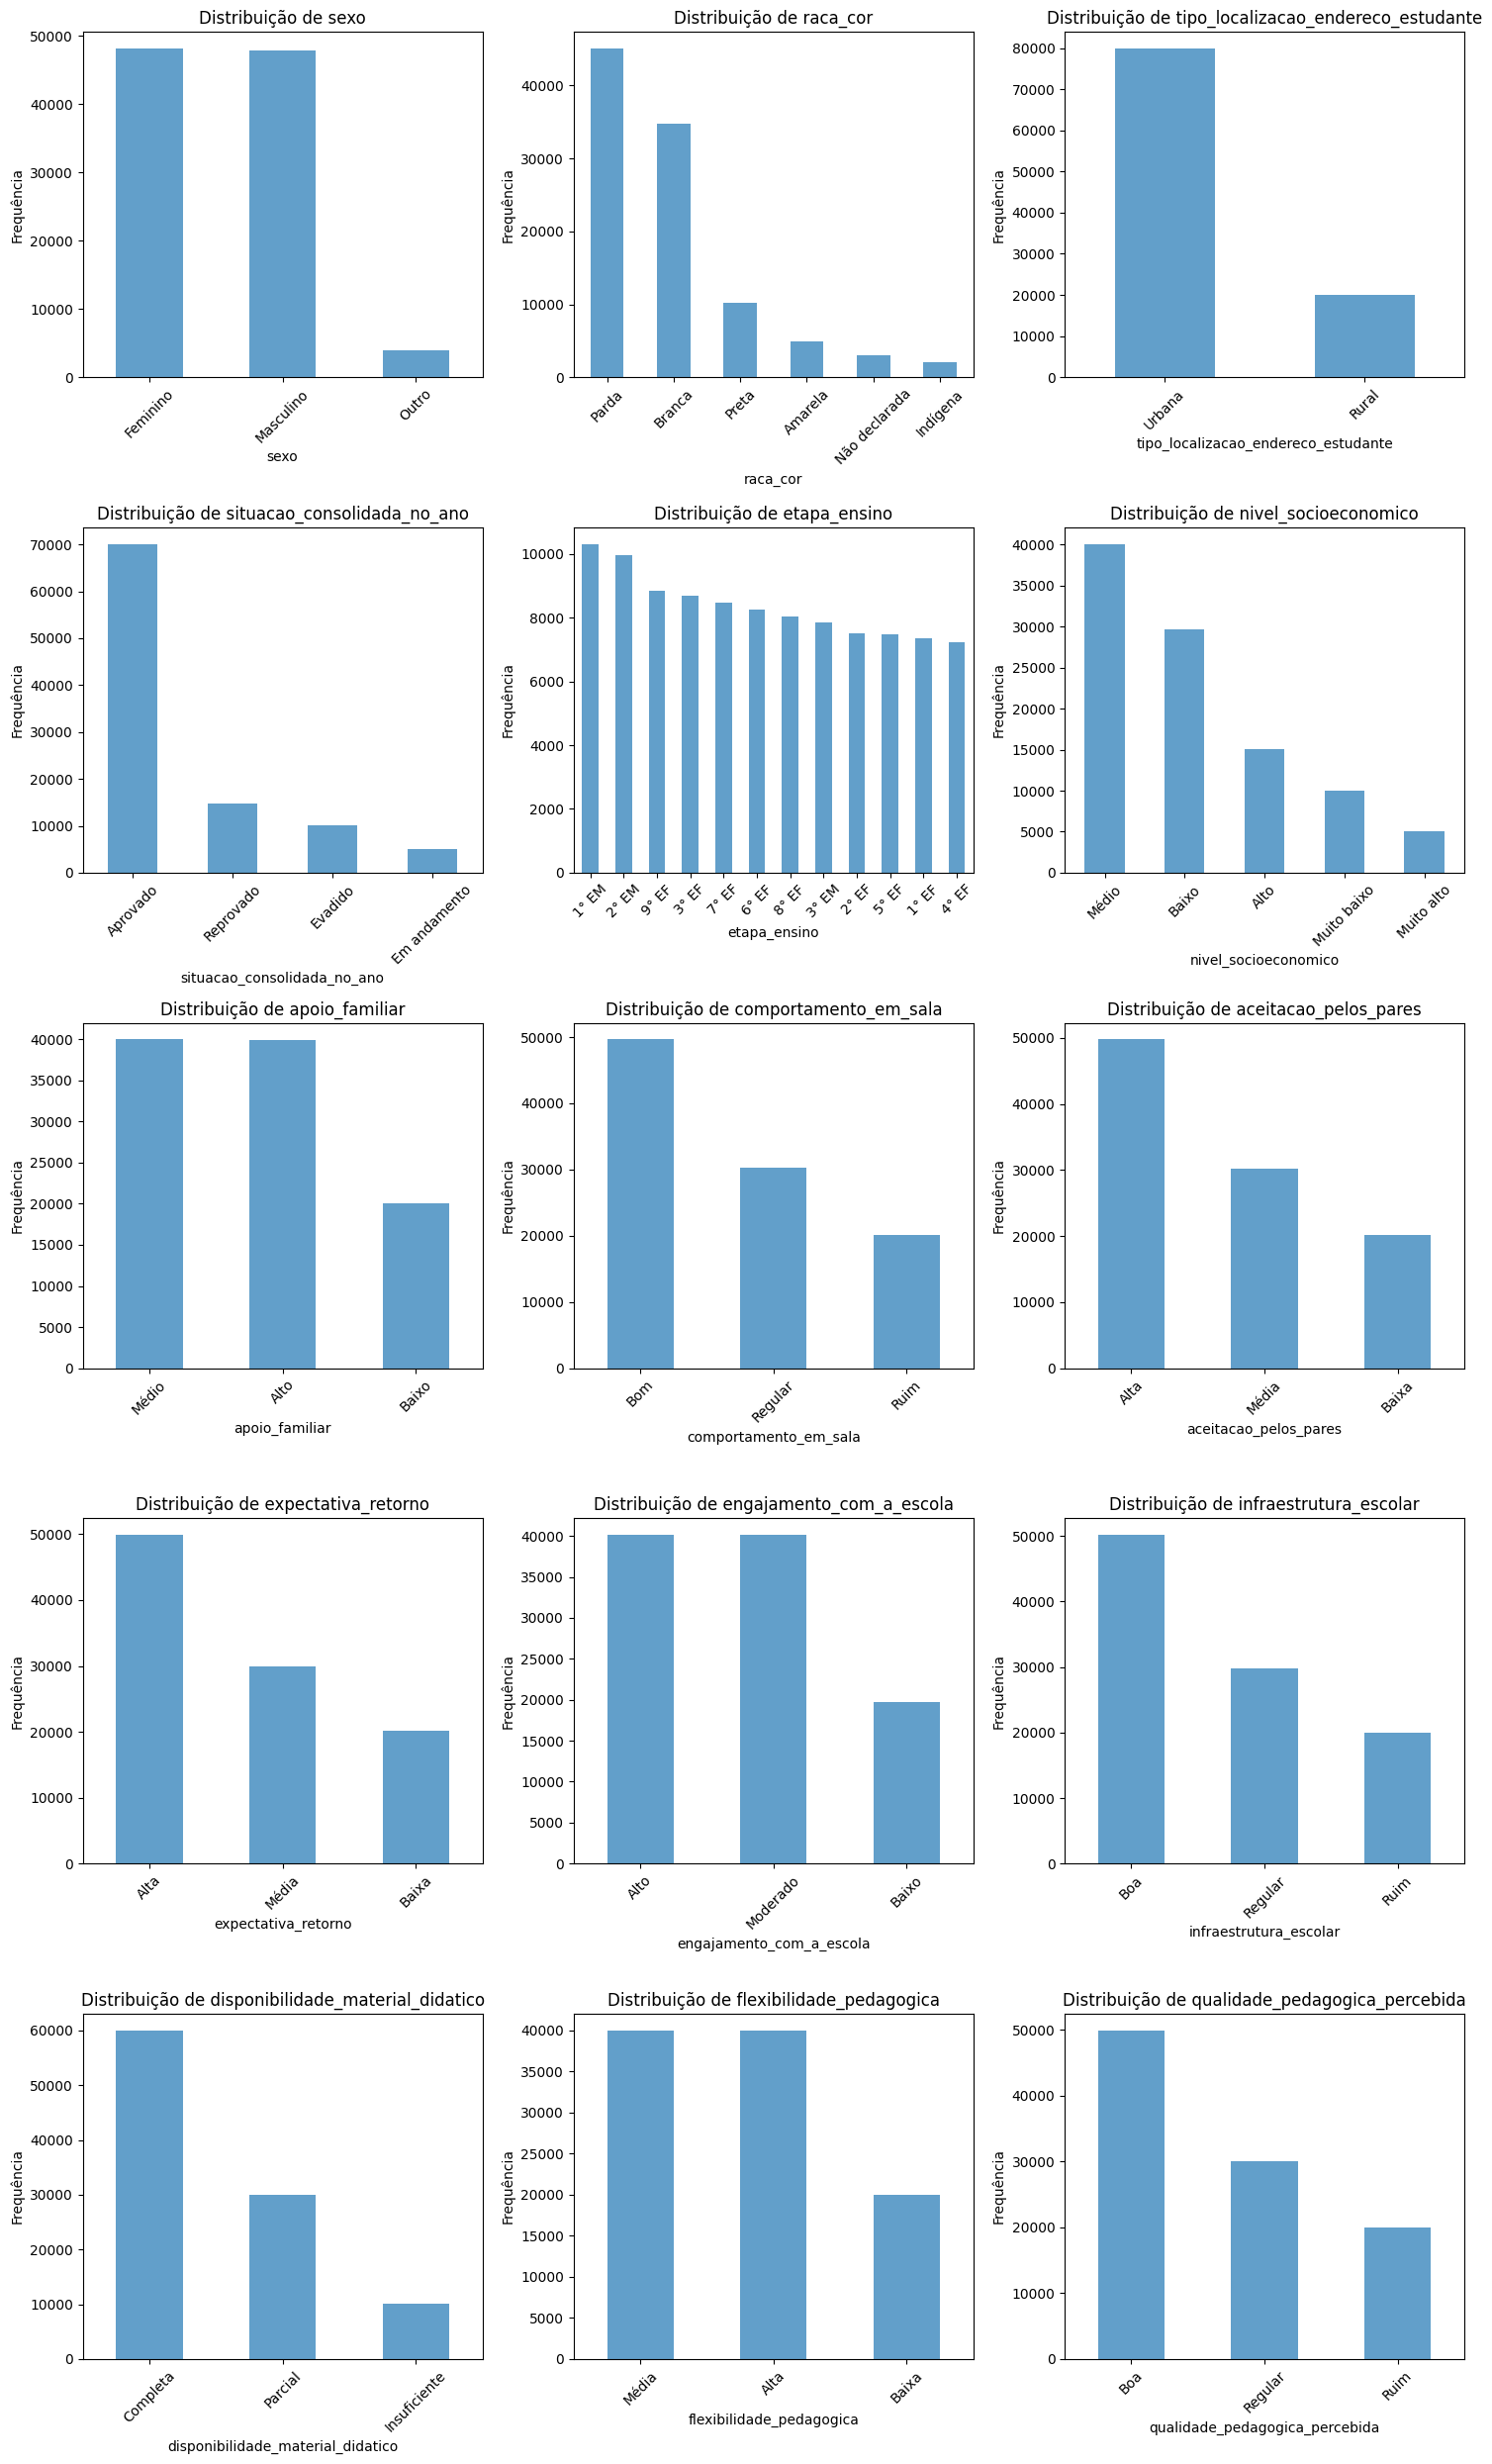

In [8]:
def plot_numerical_distributions(df):
    numerical_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = len(numerical_cols)
    n_rows = (n_cols + 2) // 3  # 3 colunas por linha
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(numerical_cols):
        df[col].hist(bins=30, ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
    
    # Remover subplots vazios
    for i in range(len(numerical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Para variáveis categóricas (gráficos de barras)
def plot_categorical_distributions(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for i, col in enumerate(categorical_cols):
        df[col].value_counts().plot(kind='bar', ax=axes[i], alpha=0.7)
        axes[i].set_title(f'Distribuição de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequência')
        axes[i].tick_params(axis='x', rotation=45)
    
    for i in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[i])
    
    plt.tight_layout()
    plt.show()

# Uso
plot_numerical_distributions(df)
print("="*10 + " Var. Categóricas " + "="*10)
plot_categorical_distributions(df)

In [9]:
# Salvar dataset em CSV
df.to_csv('dataset_evasao_sintetico.csv', index=False)
print('Dataset salvo como dataset_evasao_sintetico.csv')

Dataset salvo como dataset_evasao_sintetico.csv


## Avaliação das features

Acurácia: 0.89985

Relatório de Classificação:
              precision    recall  f1-score   support

       False       0.90      1.00      0.95     17997
        True       0.00      0.00      0.00      2003

    accuracy                           0.90     20000
   macro avg       0.45      0.50      0.47     20000
weighted avg       0.81      0.90      0.85     20000



/home/luricl/Documents/CIIA/evasao-escolar/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/luricl/Documents/CIIA/evasao-escolar/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/luricl/Documents/CIIA/evasao-escolar/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


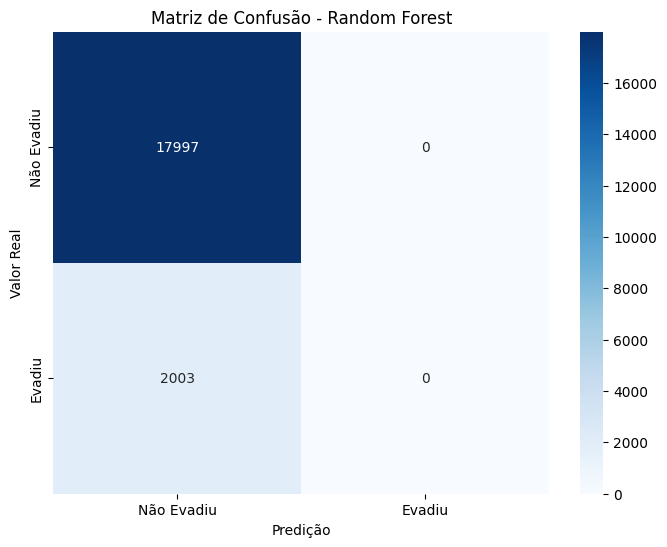

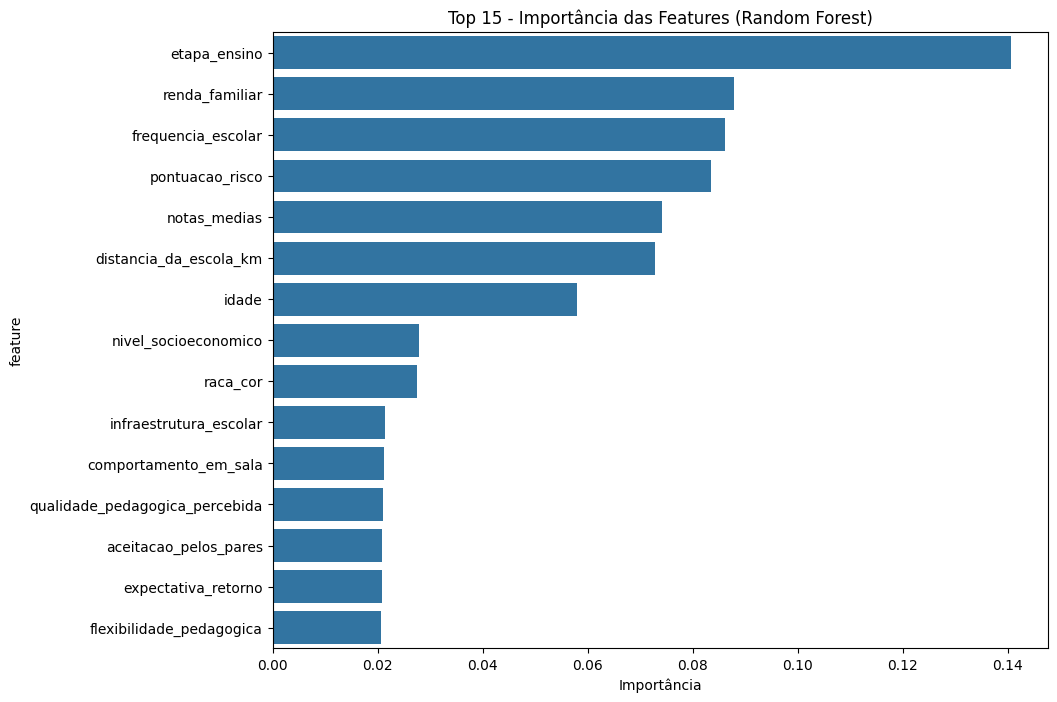


Top 10 Features mais importantes:
                   feature  importance
10            etapa_ensino    0.140561
14          renda_familiar    0.087766
11      frequencia_escolar    0.086114
33         pontuacao_risco    0.083536
12            notas_medias    0.074226
15  distancia_da_escola_km    0.072750
1                    idade    0.057976
13    nivel_socioeconomico    0.027942
6                 raca_cor    0.027541
29  infraestrutura_escolar    0.021425


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

# Preparar os dados
df_model = df.copy()

# Codificar variáveis categóricas
label_encoders = {}
categorical_columns = df_model.select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    label_encoders[col] = le

# Separar features e target
X = df_model.drop(['evasao', 'id_aluno'], axis=1)
y = df_model['evasao']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Treinar Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Fazer predições
y_pred = rf_model.predict(X_test)

# Avaliar o modelo
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Não Evadiu', 'Evadiu'], yticklabels=['Não Evadiu', 'Evadiu'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Valor Real')
plt.xlabel('Predição')
plt.show()

# Importância das features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
plt.title('Top 15 - Importância das Features (Random Forest)')
plt.xlabel('Importância')
plt.show()

print("\nTop 10 Features mais importantes:")
print(feature_importance.head(10))